### Perform Clustering

In [1]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import joblib

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, save_cluster, parameter_plot
from sensor_processing import sensor_processing

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
bounds = config_global["data"]["param_bounds"]
param_bounds = []
for key in bounds.keys():
    param_bounds.append([min(bounds[key]), max(bounds[key])])

In [3]:
# Minimum number of data points in each cluster
n_train_per_cluster = 16
n_val_per_cluster = 16
n_test_per_cluster = 128
normalize = False

In [4]:
dataset_path = os.path.join(output_dir, "datasets")
FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm = load_dataset(os.path.join(dataset_path, "Train"), normalize=normalize)
FS_val, param_val, ft_val, _, _, _ = load_dataset(os.path.join(dataset_path, "Val"), normalize, disp_norm, vel_norm, ft_norm)
FS_test, param_test, ft_test, _, _, _ = load_dataset(os.path.join(dataset_path, "Test"), normalize, disp_norm, vel_norm, ft_norm)

In [5]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

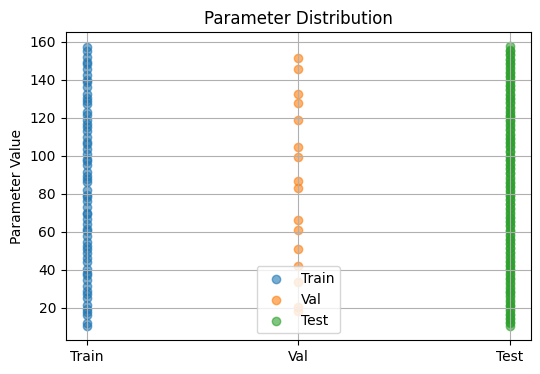

In [6]:
parameter_plot(param_train, param_val, param_test)

Perform Clustering

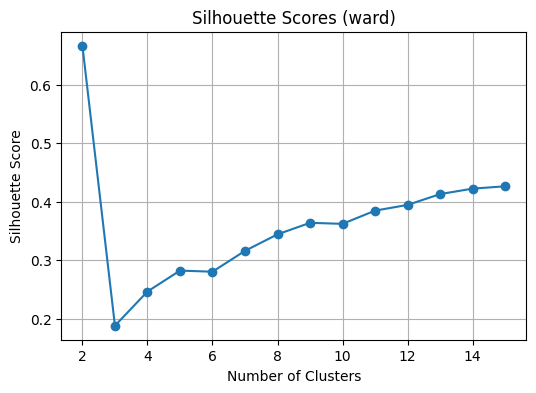

k=2, silhouette=0.667
k=3, silhouette=0.188
k=4, silhouette=0.246
k=5, silhouette=0.282
k=6, silhouette=0.280
k=7, silhouette=0.316
k=8, silhouette=0.344
k=9, silhouette=0.364
k=10, silhouette=0.362
k=11, silhouette=0.385
k=12, silhouette=0.394
k=13, silhouette=0.413
k=14, silhouette=0.422
k=15, silhouette=0.426


In [7]:
clust = Cluster(param_train, RS_train[:, 1], bounds = param_bounds, seed=config_global["seed"]) # clustering using velocity data
sil_scores = clust.find_best_k_by_silhouette(k_range=range(2, 16), method="ward")

Choose optimal number of clusters

In [8]:
n_clusters = 1

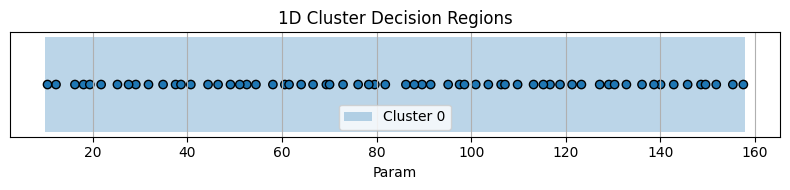

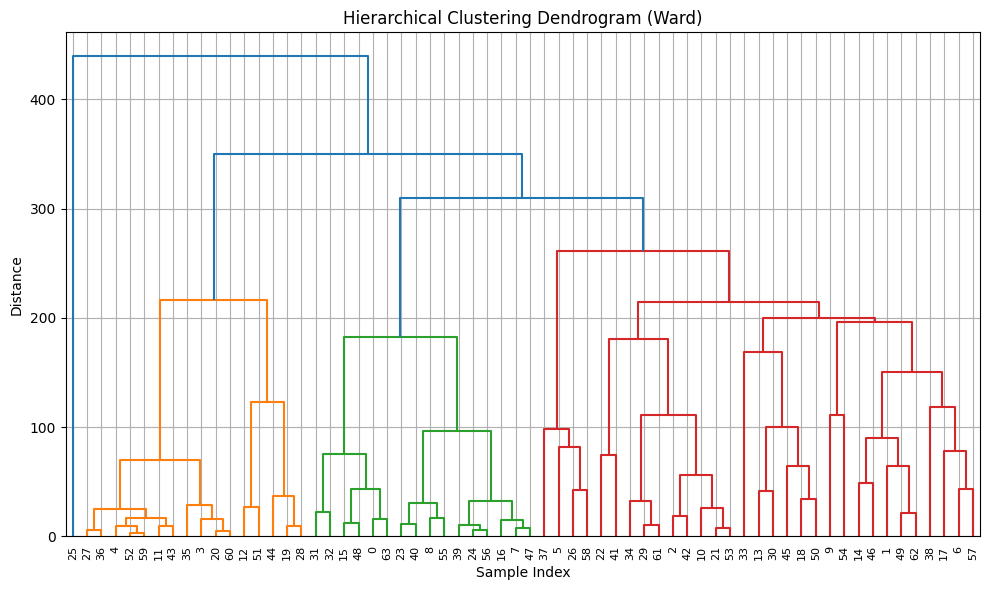

In [9]:
clust.find_clusters(n_clusters=n_clusters, method="ward")
clust.plot_decision_regions()
clust.plot_dendrogram()

In [10]:
for cluster in range(n_clusters):
    save_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, FS_val, param_val, ft_val, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, FS_test, param_test, ft_test, disp_norm, vel_norm, ft_norm)

In [11]:
n_train_per_cluster, info = clust.estimate_points_per_cluster_by_density(density=200, min_per_cluster=20)

In [12]:
n_val_per_cluster = {i: n_val_per_cluster for i in range(n_clusters + 1)}
n_test_per_cluster = {i: n_test_per_cluster for i in range(n_clusters + 1)}

##### Generate Cluster Data

In [13]:
# Train
train_data_cl, train_param_cl, train_idx_cl = clust.get_clustered_data(FS_train, param_train)
new_params_train = clust.balance_cluster_points(param_train, min_points=n_train_per_cluster, min_dist=3e-3, use_scaled_metric=True)
print("Train params calculated")

# Val
val_data_cl, val_param_cl, val_idx_cl = clust.get_clustered_data(FS_val, param_val)
new_params_val = clust.balance_cluster_points(param_val, min_points=n_val_per_cluster, min_dist=2e-4, use_scaled_metric=True)
print("Val params calculated")

# Test
test_data_cl, test_param_cl, test_idx_cl = clust.get_clustered_data(FS_test, param_test)
new_params_test = clust.balance_cluster_points(param_test, min_points=n_test_per_cluster, min_dist=1e-4, use_scaled_metric=True)
print("Test params calculated")

Train params calculated
Val params calculated
Test params calculated


In [71]:
n_train_per_cluster[7]

20

In [72]:
train_param_cl[7]

[array([12.46989941])]

In [73]:
new_params_train[7].shape


(7, 1)

from scipy.stats.qmc import Sobol

def sobol_points(n, min_val=0.0, max_val=1.0):
    # Create a Sobol sampler in 1D
    sampler = Sobol(d=1, scramble=True)
    
    # Generate n points in [0,1]
    pts = sampler.random(n)
    
    # Scale to [min_val, max_val]
    scaled = min_val + (max_val - min_val) * pts
    return scaled

# Example: 10 points in range [5, 15]
new_params_train[7] = sobol_points(19, 9.87940011, 15.08931533)

In [ ]:
#new_params_train[4] = np.vstack([new_params_train[4], 43.9963271])

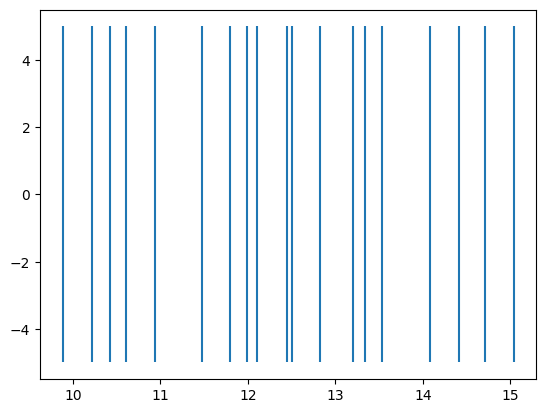

In [76]:
c=7
plt.vlines(new_params_train[c], ymin=-5, ymax=5)

In [14]:
# Create data
from beam_problem import beam_problem as bp
T_range = np.array([(2/((4**2)*np.pi), 2/np.pi)])  # Time period
w_range = 2*np.pi/(T_range) # Omega
tau_param = np.min(T_range)/5 # Impulse width range
delta_s = 1/(np.sqrt(2)) # Impulse location range
max_dt = tau_param/5 # dt
nt = config_global["data"]["nt"] # number of time steps
nx = config_global["data"]["nx"] # number of spatial points
t = np.linspace(0, max_dt * (nt), nt+1)
beam_problem = bp(nx, nt, i_range = range(1, 250), k_range = range(1, 90), vars=["omega"], upsample=True, t=t, max_dt=max_dt)

data_train_cl = []
param_train_cl = []
ft_train_cl = []
data_val_cl = []
param_val_cl = []
ft_val_cl = []
data_test_cl = []
param_test_cl = []
ft_test_cl = []
for i in range(n_clusters):
    n_train = len(train_data_cl[i]) + len(new_params_train[i])
    c_train = len(train_data_cl[i])
    d_train = n_train_per_cluster[i] - len(train_data_cl[i])
    n_val = len(val_data_cl[i])+len(new_params_val[i])
    c_val = len(val_data_cl[i])
    d_val = n_val_per_cluster[i] - len(val_data_cl[i])
    n_test = len(test_data_cl[i])+len(new_params_test[i])
    c_test = len(test_data_cl[i])
    d_test = n_test_per_cluster[i] - len(test_data_cl[i])

    data_train = np.zeros([n_train, 2, nt, nx])
    parameter_train = np.zeros([n_train, 1])
    forcing_train = np.zeros([n_train, nt, len(beam_problem.vars)+1])

    data_val = np.zeros([n_val, 2, nt, nx])
    parameter_val = np.zeros([n_val, 1])
    forcing_val = np.zeros([n_val, nt, len(beam_problem.vars)+1])

    data_test = np.zeros([n_test, 2, nt, nx])
    parameter_test = np.zeros([n_test, 1])
    forcing_test = np.zeros([n_test, nt, len(beam_problem.vars)+1])

    if c_train != 0:
        data_train[:c_train] = np.array(train_data_cl[i])
        parameter_train[:c_train] = np.array(train_param_cl[i])
        forcing_train[:c_train] = ft_train[train_idx_cl[i]]

    if c_val != 0:
        data_val[:c_val] = np.array(val_data_cl[i])
        parameter_val[:c_val] = np.array(val_param_cl[i])
        forcing_val[:c_val] = ft_val[val_idx_cl[i]]

    if c_test != 0:
        data_test[:c_test] = np.array(test_data_cl[i])
        parameter_test[:c_test] = np.array(test_param_cl[i])
        forcing_test[:c_test] = ft_test[test_idx_cl[i]]

    for j in range(c_train, n_train):
        print(f"Cluster - {i}, Train - {j-c_train+1}/{d_train}")
        data_train[j, 0], data_train[j, 1], forcing_train[j] = beam_problem.solve(tau = tau_param, s = delta_s, omega = new_params_train[i][j-c_train])
        parameter_train[j] = new_params_train[i][j-c_train]

    for j in range(c_val, n_val):
        print(f"Cluster - {i}, Val - {j-c_val+1}/{d_val}")
        data_val[j, 0], data_val[j, 1], forcing_val[j] = beam_problem.solve(tau = tau_param, s = delta_s, omega = new_params_val[i][j-c_val])
        parameter_val[j] = new_params_val[i][j-c_val]

    for j in range(c_test, n_test):
        print(f"Cluster - {i}, Test - {j-c_test+1}/{d_test}")
        data_test[j, 0], data_test[j, 1], forcing_test[j] = beam_problem.solve(tau = tau_param, s = delta_s, omega = new_params_test[i][j-c_test])
        parameter_test[j] = new_params_test[i][j-c_test]
        
    data_train_cl.append(data_train)
    param_train_cl.append(parameter_train)
    ft_train_cl.append(forcing_train)

    data_val_cl.append(data_val)
    param_val_cl.append(parameter_val)
    ft_val_cl.append(forcing_val)

    data_test_cl.append(data_test)
    param_test_cl.append(parameter_test)
    ft_test_cl.append(forcing_test)


KeyError: 0

In [81]:
len(data_train_cl)


4

In [ ]:
for idxcluster in range(n_clusters):
    save_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, data_train_cl[cluster], param_train_cl[cluster], ft_train_cl[cluster])
    save_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, data_val_cl[cluster], param_val_cl[cluster], ft_val_cl[cluster])
    save_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, data_test_cl[cluster], param_test_cl[cluster], ft_test_cl[cluster])

IndexError: list index out of range

In [47]:

joblib.dump(clust, os.path.join(output_dir, "clustering") + '/cluster_model.pkl')

['c:\\Users\\haida\\Desktop\\EDM_NODE_DATA_MOD\\EDM_NODE_Data\\beam_node\\Examples\\omega\\Outputs\\clustering/cluster_model.pkl']

In [48]:
config_global["data"]["n_clusters"] = n_clusters
save_config(config_file, config_global)